## 데이터 전처리 
- 데이터를 분석하기 좋은 형태로 가공하는 과정이다
- 원본 데이터를 그대로 사용하는 것이 아니라
  이상치 , 중복데이터 , 결측치 등을 처리해서 신뢰할 수 있는 데이터로 만드는 과정을 의미한다

## 이상치(outlier)
- 관측하거나 수집한 데이터의 범위(군집)에서 많이 벗어나있는 아주 작은 값 또는 큰 값을 의미한다
- 이상치는 제거하거나 대체하거나 또는 가만히 놔두어도 상관없는 지를 판단하여 전처리를 진행해야 한다 

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRuY-LwTufVlKJ-r54472gZtIxK7CuP0Ei6gVwSRUy8zWdl1koZIG6VzpR6&s=10" />

In [39]:
# 비어있는 값을 채우거나 없애거나 해야함  -> 최빈값으로 채움 

## 예측
- 숫자로 알기 힘든 값들을 표현하기 위해 기술통계량을 확인하는 것을 의미한다
- min(최소), max(최대), median(최빈), mean(평균)

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [68]:
# # 윈도우 맑은 고딕 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 맥 애플고딕 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

## 박스 플롯
- 이상치를 탐색하고 사용되는 시각화 차트이다
- 분위수를 기준으로 그려지고 , 상자 안에 그려져 있는 직선이 중위수(Median)을 나타낸다. Median 값의 위치에 따라 값들의 분포를 확인 할 수 있다
- 상자의 밑변은 1분위수이고 , 윗 변은 3분위수 를 의미한다
- 상자의 중심으로 위 아래에 직선이 있는것을 본 수 있는데 이것을 울타리라고 부른다

## 이산치 계산 공식 
- 아래 이상치 공식 Q1 - (1.5 * IQR)
- 위 이상치 공식 Q3 + (1.5 * IQR)


<img style="width:500px;" src="https://blog.kakaocdn.net/dna/dLPevN/btq1caAZMWD/AAAAAAAAAAAAAAAAAAAAACdUyXIwIBA0UI-lNOxgEND-ivrCO7oAkDQNWYlbYDTf/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=o4DIu2hQNUV89WOVQAkr5VNdrvg%3D" />

In [69]:
height_list = [181, 280, 158, 110, 170, 160, 155, 145]
avg_height = sum(height_list) / len(height_list)

print(f"평균 키 : {avg_height}cm")
print(f"평균 키 : {min(height_list)}cm")
print(f"평균 키 : {max(height_list)}cm")

평균 키 : 169.875cm
평균 키 : 110cm
평균 키 : 280cm


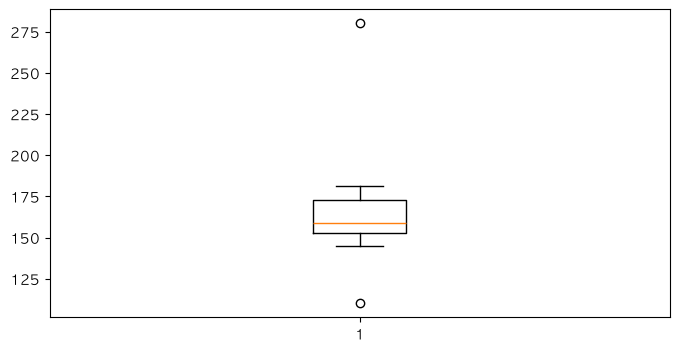

In [70]:
plt.figure(figsize=(8, 4))

# 박스 플롯 이상치 탑지 
plt.boxplot(height_list)
plt.show()

# iqr : 1 ~ 3 분위

In [71]:
height_list = [181, 158, 170, 160, 155, 145]
avg_height = sum(height_list) / len(height_list)

print(f"평균 키 : {avg_height}cm")
print(f"평균 키 : {min(height_list)}cm")
print(f"평균 키 : {max(height_list)}cm")

평균 키 : 161.5cm
평균 키 : 145cm
평균 키 : 181cm


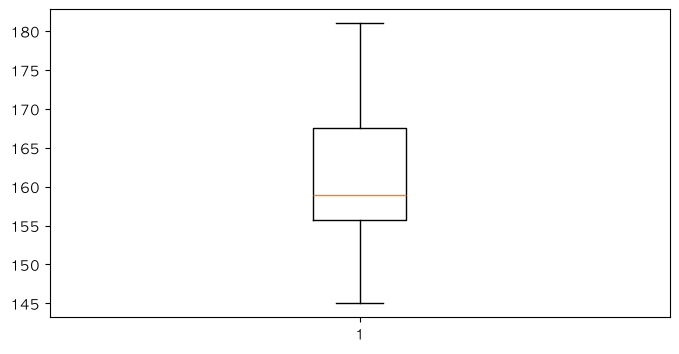

In [72]:
plt.figure(figsize=(8, 4))

plt.boxplot(height_list)
plt.show()

## Outliner (이상치)처리 방법 
1. 값을 그대로 냅둔다 
2. 값을 제거하는 방법 (신뢰도 저하 , 데이터 버려지는 단점이 있다)

## 결측치(Outliner)
- 데이터 수집 또는 데이터셋에서 Mull, MaN 값이 들어가 비어있는 상태를 의미한다
- 데이터를 수집하는 과정에서 오류 , 누락, 값을 저장하는 과정에서 소실하는 것을 의미하며 분석전에 반드시 처리해야 한다
- 대체하다면 평균값을, 최빈값, 중앙값 같은 통계 수치나 머신러닝의 예측값 중 적절한 데이터의 특성을 고려하여 대체해야 한다 

![](https://drive.google.com/thumbnail?id=1Xu3g-0MJOJxcXr330-JecGN_nI7Yqoos&sz=w1000)

In [73]:
df = pd.DataFrame({
    "이름": ["시츄", "상아", "진성", "혜진", "슬기", "우영", "수민"],
    "소득": [1000000, 55000, None, None, 100000, 50000, 3000]
})
df

,이름,소득
0,시츄,1000000.0
1,상아,55000.0
2,진성,NaN
3,혜진,NaN
4,슬기,100000.0
5,우영,50000.0
6,수민,3000.0


In [74]:
# NaN이 있는지 없는지 확인 하는 메서드 
df.isna().sum()


이름    0
소득    2
dtype: int64

In [75]:
# 결측치 삭제 (NaN을 없앤다) -> 복사본으로해서 삭제 
df2 = df.dropna()
df2

,이름,소득
0,시츄,1000000.0
1,상아,55000.0
4,슬기,100000.0
5,우영,50000.0
6,수민,3000.0


In [76]:
# 평퓬 구하기 
df["소득"].mean()
df

,이름,소득
0,시츄,1000000.0
1,상아,55000.0
2,진성,NaN
3,혜진,NaN
4,슬기,100000.0
5,우영,50000.0
6,수민,3000.0


In [77]:
# 평균 값으로 채우겠다           # ('na')비어있는거 다 ('fill')채우겠다
df.fillna(df["소득"].mean())
df

,이름,소득
0,시츄,1000000.0
1,상아,55000.0
2,진성,NaN
3,혜진,NaN
4,슬기,100000.0
5,우영,50000.0
6,수민,3000.0


## 최빈값 : .mode()

In [78]:
df["소득"].mode()[0]

np.float64(3000.0)

In [79]:
df.fillna(df["소득"].mode()[0])

,이름,소득
0,시츄,1000000.0
1,상아,55000.0
2,진성,3000.0
3,혜진,3000.0
4,슬기,100000.0
5,우영,50000.0
6,수민,3000.0


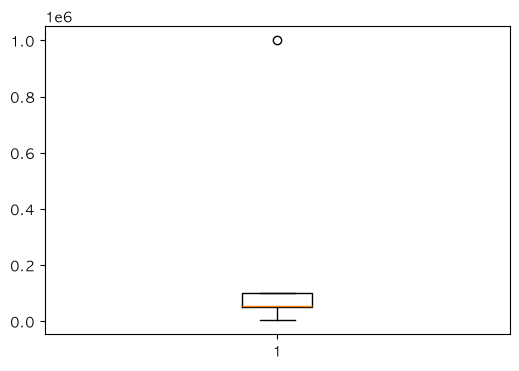

In [80]:
plt.figure(figsize=(6, 4))
# plt.boxplot(df2["소득"])
plt.boxplot(df.dropna()["소득"])

plt.show()

## 중간값 : .median()

In [81]:
df["소득"].median()

np.float64(55000.0)

In [83]:
df.fillna(df["소득"].median())

,이름,소득
0,시츄,1000000.0
1,상아,55000.0
2,진성,55000.0
3,혜진,55000.0
4,슬기,100000.0
5,우영,50000.0
6,수민,3000.0


# 중복 데이터 
- 동일한 데이터가 여러번 저장된 상태를 의미합니다
- 중복 데이터가 많아지면 통계 결과와 왜곡된 분석 결과 및 신뢰도가 떨어질 수 있습니다.

<img src="https://drive.google.com/thumbnail?id=1OyllE-RqUt-47NRgJ0N2oyXHKrvic3db&sz=w1000" width=1000>

In [84]:
df = pd.DataFrame({
    "이름" : ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미" : ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})
df

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
4,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭
8,지호,코딩
9,상아,알바


In [85]:

df.duplicated()

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

In [86]:
df.duplicated().sum()

np.int64(3)

In [87]:
df2 = df.drop_duplicates()
df2

,이름,취미
0,지호,코딩
1,승현,칵테일
2,상아,알바
3,우영,코딩
5,준승,코딩
6,예나,코딩
7,수민,스트레칭


In [88]:
df = pd.DataFrame({
    "학번" : [i + i for i in range(10)],
    "이름" : ["지호", "승현", "상아", "우영", "우영", "준승", "예나", "수민", "지호", "상아"],
    "취미" : ["코딩", "칵테일", "알바", "코딩", "코딩", "코딩", "코딩", "스트레칭", "코딩", "알바"]
})
df

,학번,이름,취미
0,0,지호,코딩
1,2,승현,칵테일
2,4,상아,알바
3,6,우영,코딩
4,8,우영,코딩
5,10,준승,코딩
6,12,예나,코딩
7,14,수민,스트레칭
8,16,지호,코딩
9,18,상아,알바


In [89]:
# 이름 취미가 같은 사람을 기준으로 중복값 설정 
df2 = df.drop_duplicates(subset=["이름", "취미"])
df2


,학번,이름,취미
0,0,지호,코딩
1,2,승현,칵테일
2,4,상아,알바
3,6,우영,코딩
5,10,준승,코딩
6,12,예나,코딩
7,14,수민,스트레칭


In [90]:
df.duplicated(subset=["이름", "취미"])

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8     True
9     True
dtype: bool

In [91]:
df2 = df.drop_duplicates()
df2

,학번,이름,취미
0,0,지호,코딩
1,2,승현,칵테일
2,4,상아,알바
3,6,우영,코딩
4,8,우영,코딩
5,10,준승,코딩
6,12,예나,코딩
7,14,수민,스트레칭
8,16,지호,코딩
9,18,상아,알바


## 데이터 전처리 연습

In [96]:
import os
# 1. 경로 잡기
base_path = r"//Users/kdt_0900_lyn/data_analysis/resource/dataset"
file_name = r"preprocessing.csv"

file_path = os.path.join(base_path, file_name)

In [97]:
df1 = pd.read_csv(file_path)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


## 1단계. 칼럼 타입 확인 
- 각 컬럼이 수치형(Numerrical)인지, 범주형/분류형(Categorical)인지 확인해야 한다
- 그 이유는 대체값(Imputation) 전략이 달라지기 때문이다
  
1. 수치형 데이터: 평균값 또는 중앙값 또는 특성값으로 대체
2. 범주형 데이터 : 최빈값, 번주 추가하여 처리

In [122]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      30 non-null     int64  
 1   name    30 non-null     str    
 2   age     29 non-null     float64
 3   gender  30 non-null     str    
 4   city    29 non-null     str    
 5   salary  29 non-null     float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.5 KB


In [123]:
# 속성 = 특성 = feture

In [124]:
# 기술통계량
df1.describe()

,id,age,salary
count,30.000000,29.000000,29.000000
mean,15.500000,62.413793,38237.896552
std,8.803408,180.348575,184974.502563
min,1.000000,-5.000000,2700.000000
25%,8.250000,26.000000,3400.000000
50%,15.500000,29.000000,3700.000000
75%,22.750000,34.000000,4500.000000
max,30.000000,999.000000,999999.000000


## 2단계, 각 컬럼 타입의 계획 수립 
- id: int - 분류형
- name: str - 분류형
- age: float -> int - 수치형
- gender: str - 분류형
- city: str - 분류형
- salary: int - 수치형

## 3단걔, 이상치, 결측치, 중복값을 확인 

In [125]:
# age , city , salary : 결측치가 있다 
df1.isna().sum()

id        0
name      0
age       1
gender    0
city      1
salary    1
dtype: int64

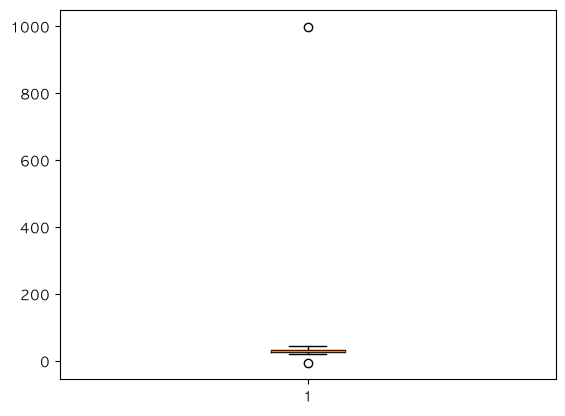

In [126]:
# age 에는 이상치가 있다 
plt.boxplot(df1["age"].dropna())
plt.show()

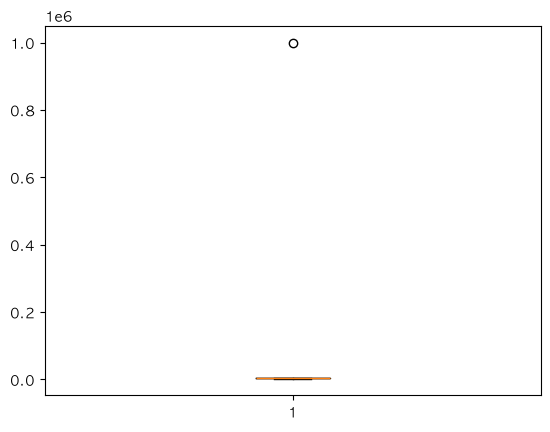

In [127]:
# salary에는 이상치가 있다 
plt.boxplot(df1["salary"].dropna())
plt.show()

In [128]:
# 1염의 중복 데이터가 있다 
df1.duplicated(subset=["name", "age", "gender", "city"]).sum()

np.int64(1)

## 4단계, 결측치 대체 

In [129]:
# age , city , salary : 결측치가 있다
# age : 수치형 데이터 ⭐️
# -> 중앙값(median) 대체 가능 , ( 평균 구할 수 있음xxx , 최빈값은 사용 xxx)

age_nedian = df1["age"].median()
df1["age"] = df1["age"].fillna(age_nedian)
df1

# 11번 중앙 값으로 바뀜


,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [130]:
# 결측치 대체됨 
df1.loc[11]

id            12
name         이다은
age         29.0
gender         여
city          성남
salary    3900.0
Name: 11, dtype: object

In [131]:
# 분류형 데이터 ⭐️
# - 최빈값(mode), 새로운 컬럼 생성

city_mode = df1["city"].mode()[0]
city_mode


'서울'

In [132]:
# NaN -> cicity_mode로 채우기 
df1["city"]= df1["city"].fillna(city_mode)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [133]:
# salary 대체값 넣기
salary_nedian = df1["salary"].median()
df1["salary"] = df1["salary"].fillna(salary_nedian)
df1

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,7,오세훈,45.0,남,서울,5500.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0


In [134]:
df1.loc[11]

id            12
name         이다은
age         29.0
gender         여
city          성남
salary    3900.0
Name: 11, dtype: object

## 컬럼의 형 변환 

In [ ]:
# .astype(int) : 정수로 형 변환 
df1["age"] = df1["age"].astype(int)
df1["salary"] = df1["salary"].astype(int)
df1

## 5단꼐, 이상치 대체 또는 제거 

In [ ]:
# IQR = Q3 - Q1
# 이상치 판단 : Q3 + (1.5 * IQR)

In [102]:
# quantile() : 전체 데이터를 크기 순서대로 정렬한 뒤, 이를 일정한 비율이나 구간으로 나누어 주는 기준이 되는 수치
Q1 = df1["salary"].quantile(0.25)
Q3 = df1["salary"].quantile(0.75)
IQR = Q3 - Q1

print(f"1사분위 값: {Q1}")
print(f"3사분위 값: {Q3}") # = 경계선 
print(f"IQR: {IQR}")

1사분위 값: 3400.0
3사분위 값: 4500.0
IQR: 1100.0


In [112]:
min_outlier = Q1 - (IQR * 1.5)
max_outlier = Q3 + (IQR * 1.5)

print(f"max outlier: {max_outlier}초과")
print(f"min outlier: {min_outlier}이하")

max outlier: 6150.0초과
min outlier: 1750.0이하


In [113]:
# boolin_mask
outlier_mask = (df1["salary"] > max_outlier) | (df1["salary"] < min_outlier)
df1["salary"][outlier_mask]

27    999999.0
Name: salary, dtype: float64

In [114]:
def remove_outlier(df, col_name):
    df_copy = df.copy()
    Q1 = df_copy[col_name].quantile(0.25)
    Q3 = df_copy[col_name].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    mask = ~((df_copy[col_name] < lower) | (df_copy[col_name] > upper))
    return df_copy[mask]

In [116]:
df2 = remove_outlier(df1, "salary")
df3 = remove_outlier(df2, "age")
df3

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
7,8,강민지,22.0,여,부산,2800.0
8,9,윤성호,38.0,남,울산,4900.0
9,10,송지수,26.0,여,서울,3400.0
10,11,김도윤,30.0,남,수원,4000.0


In [117]:
df4 = df3.reset_index(drop=True)
df4

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,8,강민지,22.0,여,부산,2800.0
7,9,윤성호,38.0,남,울산,4900.0
8,10,송지수,26.0,여,서울,3400.0
9,11,김도윤,30.0,남,수원,4000.0


## 중복값 삭제 

In [121]:
df4.duplicated(subset=["name", "age", "gender", "city"])  # 확인 

# 중복값 삭제, 인덱스 초기화해서 다시 붙이기  
# .reset_index(drop=True)   : 인덱스 재설정 
df5 = df4.drop_duplicates(subset=["name", "age", "gender", "city"]).reset_index(drop=True)  # 삭제 
df5

,id,name,age,gender,city,salary
0,1,김철수,28.0,남,서울,3500.0
1,2,이영희,31.0,여,부산,4200.0
2,3,박민수,25.0,남,대구,3000.0
3,4,최지은,29.0,여,인천,3800.0
4,5,정수현,34.0,남,광주,4500.0
5,6,한유진,27.0,여,대전,3600.0
6,8,강민지,22.0,여,부산,2800.0
7,9,윤성호,38.0,남,울산,4900.0
8,10,송지수,26.0,여,서울,3400.0
9,11,김도윤,30.0,남,수원,4000.0
